# EOD Zootopia - Visualisation des résultats

> **Analyse du dispatching électrique optimal**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11

print("✅ Imports complets")

✅ Imports complets


In [2]:
# Palette de couleurs cohérente
colors_prod = {
    'P_nuc': '#E74C3C',
    'P_charbon': '#34495E',
    'P_ccg': '#FFDC2E',
    'P_tac': '#F1C40F',
    'P_cogen': '#9B59B6',
    'P_fioul': '#7F8C8D',
    'P_eolien': "#5EBFFF",
    'P_solaire': '#E67E22',
    'P_dechets': '#8B6F47',
    'P_biomasse': '#27AE60',
    'Phy_fdl': "#0300B7",
    'Phy_lac': "#0076BA",
    'Pdecharge_STEP': '#2ECC71',
}

colors_scenario = {'dry': '#E74C3C', 'normal': '#3498DB', 'wet': '#27AE60'}

def load_results(scenario):
    try:
        df = pd.read_csv(f"../results/results_{scenario}.csv")
        
        # Vérifier les colonnes STEP
        step_decharge = df['Pdecharge_STEP'].sum()/1e6 if 'Pdecharge_STEP' in df.columns else 0
        step_charge = df['Pcharge_STEP'].sum()/1e6 if 'Pcharge_STEP' in df.columns else 0
        
        print(f"✅ {scenario.upper():8} | {len(df):5} heures | " +
              f"Défaillance: {df['Puns'].sum()/1e6:6.2f} TWh | " +
              f"Spill: {df['Pspill'].sum()/1e6:6.2f} TWh | " +
              f"STEP: {step_charge:6.2f}↑ / {step_decharge:6.2f}↓ TWh")
        return df
    except Exception as e:
        print(f"❌ results_{scenario}.csv non trouvé ({str(e)})")
        return None

print("\n📂 CHARGEMENT DES DONNÉES\n")
results = {s: load_results(s) for s in ['dry', 'normal', 'wet']}
results = {k: v for k, v in results.items() if v is not None}
print(f"\n✓ {len(results)}/3 scénarios chargés")


📂 CHARGEMENT DES DONNÉES

✅ DRY      |  8760 heures | Défaillance:   0.00 TWh | Spill:   0.00 TWh | STEP:   0.01↑ /   1.04↓ TWh
✅ NORMAL   |  8760 heures | Défaillance:   0.00 TWh | Spill:   0.00 TWh | STEP:   0.01↑ /   1.01↓ TWh
✅ WET      |  8760 heures | Défaillance:   0.00 TWh | Spill:   0.00 TWh | STEP:   0.06↑ /   1.04↓ TWh

✓ 3/3 scénarios chargés


---

## 🎯 Vue d'Ensemble - Statistiques Clés

In [3]:
# Tableau récapitulatif
print("\n" + "="*120)
print("STATISTIQUES ANNUELLES PAR SCÉNARIO")
print("="*120 + "\n")

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    
    print(f"\n{'🔴 ' if scenario == 'dry' else '🔵 ' if scenario == 'normal' else '🟢 '}{scenario.upper()}")
    print("-" * 120)
    
    # Charge
    print(f"\n  ⚡ CHARGE")
    print(f"     Min/Moy/Max : {df['load'].min():>8.0f} / {df['load'].mean():>8.0f} / {df['load'].max():>8.0f} MW")
    print(f"     Total       : {df['load'].sum()/1e6:>8.2f} TWh")
    
    # Production (sans STEP)
    cols_prod = ['P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul',
                 'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'Phy_fdl', 'Phy_lac']
    prod_total = df[[c for c in cols_prod if c in df.columns]].sum().sum() / 1e6
    step_decharge = df['Pdecharge_STEP'].sum() / 1e6 if 'Pdecharge_STEP' in df.columns else 0
    prod_total_avec_step = prod_total + step_decharge
    
    print(f"\n  🔋 PRODUCTION")
    print(f"     Sources (sans STEP) : {prod_total:>8.2f} TWh")
    print(f"     STEP décharge      : {step_decharge:>8.2f} TWh")
    print(f"     Total              : {prod_total_avec_step:>8.2f} TWh")
    print(f"     Couverture         : {100*prod_total_avec_step/(df['load'].sum()/1e6):>8.1f}%")
    
    # ENR
    enr = (df['P_eolien'].sum() + df['P_solaire'].sum()) / 1e6
    print(f"\n  🌬️  ENR")
    print(f"     Éolien      : {df['P_eolien'].sum()/1e6:>8.2f} TWh")
    print(f"     Solaire     : {df['P_solaire'].sum()/1e6:>8.2f} TWh")
    print(f"     Total       : {enr:>8.2f} TWh ({100*enr/prod_total:>5.1f}%)")
    
    # Hydraulique
    hydro = (df['Phy_fdl'].sum() + df['Phy_lac'].sum()) / 1e6
    print(f"\n  💧 HYDRAULIQUE")
    print(f"     FDL/Lacs    : {df['Phy_fdl'].sum()/1e6:>8.2f} / {df['Phy_lac'].sum()/1e6:>8.2f} TWh")
    print(f"     Total       : {hydro:>8.2f} TWh ({100*hydro/prod_total:>5.1f}%)")
    print(f"     Stock moy   : {df['stock_hydro'].mean()/1e6:>8.2f} TWh")
    
    # STEP
    step_charge = df['Pcharge_STEP'].sum() / 1e6 if 'Pcharge_STEP' in df.columns else 0
    step_stock_moy = df['stock_STEP'].mean() / 1e6 if 'stock_STEP' in df.columns else 0
    rendement = (step_decharge / step_charge * 100) if step_charge > 0 else 0
    
    print(f"\n  🔋 STEP")
    print(f"     Charge      : {step_charge:>8.2f} TWh")
    print(f"     Décharge    : {step_decharge:>8.2f} TWh")
    print(f"     Rendement   : {rendement:>8.1f}%")
    print(f"     Stock moy   : {step_stock_moy:>8.2f} TWh")
    
    # Défaillance & spill
    print(f"\n  🔴 FIABILITÉ")
    print(f"     Défaillance : {df['Puns'].sum()/1e6:>8.2f} TWh ({100*df['Puns'].sum()/(df['load'].sum()):>5.2f}%)")
    print(f"     Spill hydro : {df['Pspill'].sum()/1e6:>8.2f} TWh")

print(f"\n{'='*120}\n")


STATISTIQUES ANNUELLES PAR SCÉNARIO


🔴 DRY
------------------------------------------------------------------------------------------------------------------------

  ⚡ CHARGE
     Min/Moy/Max :     5723 /     9713 /    16934 MW
     Total       :    85.09 TWh

  🔋 PRODUCTION
     Sources (sans STEP) :    79.70 TWh
     STEP décharge      :     1.04 TWh
     Total              :    80.73 TWh
     Couverture         :     94.9%

  🌬️  ENR
     Éolien      :    12.95 TWh
     Solaire     :     4.80 TWh
     Total       :    17.76 TWh ( 22.3%)

  💧 HYDRAULIQUE
     FDL/Lacs    :     4.15 /     3.53 TWh
     Total       :     7.68 TWh (  9.6%)
     Stock moy   :     0.34 TWh

  🔋 STEP
     Charge      :     0.01 TWh
     Décharge    :     1.04 TWh
     Rendement   :  15500.1%
     Stock moy   :     0.02 TWh

  🔴 FIABILITÉ
     Défaillance :     0.00 TWh ( 0.00%)
     Spill hydro :     0.00 TWh

🔵 NORMAL
-------------------------------------------------------------------------------------

---

## 📈 Comparaison Hiver vs Été - EOD Empilée

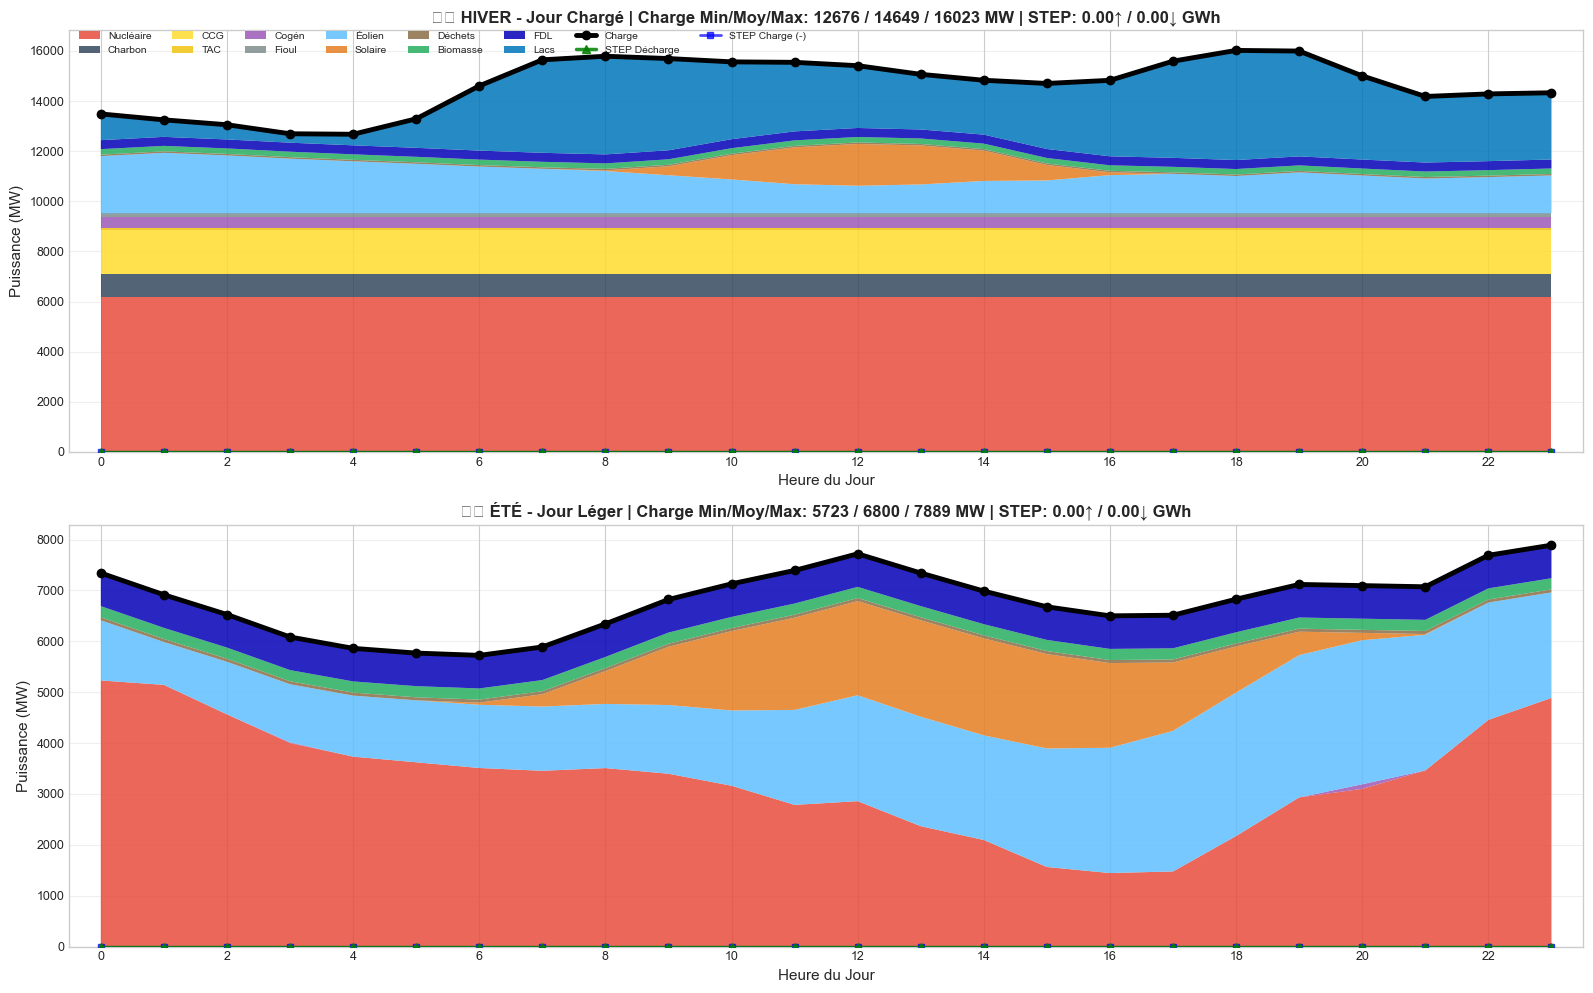


🔍 CONTRASTE HIVER vs ÉTÉ

HIVER:
  Charge      : moy 14649 MW | pic 16023 MW | min 12676 MW
  Solaire     : 333 MW
  Éolien      : 1648 MW
  STEP        : 0.00↑ / 0.00↓ GWh

ÉTÉ:
  Charge      : moy 6800 MW | pic 7889 MW | min 5723 MW
  Solaire     : 728 MW
  Éolien      : 1850 MW
  STEP        : 0.00↑ / 0.00↓ GWh

DÉCALAGES CLÉS:
  Charge      : +115.4%
  Solaire     : +118.8%
  STEP charge : N/A


In [4]:
scenario = 'normal'
df = results[scenario]

# Trouver jours caractéristiques
winter_day = df[df['month'] == 12].nlargest(1, 'load').index[0]
winter_start = (winter_day // 24) * 24
winter_hours = slice(winter_start, winter_start + 24)

summer_day = df[df['month'] == 7].nsmallest(1, 'load').index[0]
summer_start = (summer_day // 24) * 24
summer_hours = slice(summer_start, summer_start + 24)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

production_cols = ['P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul',
                   'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'Phy_fdl', 'Phy_lac']

for idx, (hours, title) in enumerate([(winter_hours, '❄️ HIVER - Jour Chargé'),
                                       (summer_hours, '☀️ ÉTÉ - Jour Léger')]):
    ax = axes[idx]
    data = df.iloc[hours][production_cols]
    
    # Stackplot production classique
    ax.stackplot(range(24), *[data[col] for col in production_cols],
                 labels=production_cols, 
                 colors=[colors_prod.get(col, '#999') for col in production_cols],
                 alpha=0.85)
    
    # Courbe de charge (demande)
    ax.plot(range(24), df.iloc[hours]['load'], 'k-', linewidth=3.5, label='Charge', 
            marker='o', markersize=6, zorder=10)
    
    # STEP décharge (ajout à la production)
    if 'Pdecharge_STEP' in df.columns:
        step_decharge = df.iloc[hours]['Pdecharge_STEP']
        ax.plot(range(24), step_decharge, 'g^-', linewidth=2.5, label='STEP Décharge', 
                markersize=6, alpha=0.85, zorder=9)
    
    # STEP charge (soustrait de la production)
    if 'Pcharge_STEP' in df.columns:
        step_charge = df.iloc[hours]['Pcharge_STEP']
        ax.plot(range(24), -step_charge, 'bs-', linewidth=2, label='STEP Charge (-)', 
                markersize=5, alpha=0.7, zorder=8)
    
    # Défaillance (si > 0)
    if 'Puns' in df.columns:
        defaillance = df.iloc[hours]['Puns']
        if defaillance.sum() > 0:
            défail_indices = defaillance[defaillance > 0].index
            for d_idx in défail_indices:
                ax.axvline(x=d_idx - hours.start, color='red', alpha=0.5, linewidth=3, linestyle='--')
    
    charge_moy = df.iloc[hours]['load'].mean()
    charge_pic = df.iloc[hours]['load'].max()
    charge_min = df.iloc[hours]['load'].min()
    
    # Stats STEP
    step_charge_total = df.iloc[hours]['Pcharge_STEP'].sum() if 'Pcharge_STEP' in df.columns else 0
    step_decharge_total = df.iloc[hours]['Pdecharge_STEP'].sum() if 'Pdecharge_STEP' in df.columns else 0
    
    ax.set_title(f"{title} | Charge Min/Moy/Max: {charge_min:.0f} / {charge_moy:.0f} / {charge_pic:.0f} MW | " +
                f"STEP: {step_charge_total/1e6:.2f}↑ / {step_decharge_total/1e6:.2f}↓ GWh",
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Puissance (MW)', fontsize=11)
    ax.set_xlabel('Heure du Jour', fontsize=11)
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(-0.5, 23.5)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)  # Ligne zéro pour STEP charge
    ax.grid(True, alpha=0.3, axis='y')
    
    # Légende séparée (sans surcharge)
    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        # Garder uniquement les sources importantes + charge + STEP
        labels_clean = ['Nucléaire', 'Charbon', 'CCG', 'TAC', 'Cogén', 'Fioul',
                       'Éolien', 'Solaire', 'Déchets', 'Biomasse', 'FDL', 'Lacs', 'Charge',
                       'STEP Décharge', 'STEP Charge (-)']
        
        ax.legend(handles[-len(labels_clean):], labels_clean, 
                 loc='upper left', fontsize=7.5, ncol=8, framealpha=0.95, 
                 bbox_to_anchor=(0, 1.02))

plt.tight_layout()
plt.show()

print(f"\n🔍 CONTRASTE HIVER vs ÉTÉ\n")
hiver_load = df.iloc[winter_hours]['load']
ete_load = df.iloc[summer_hours]['load']
hiver_solar = df.iloc[winter_hours]['P_solaire'].mean()
ete_solar = df.iloc[summer_hours]['P_solaire'].mean()
hiver_wind = df.iloc[winter_hours]['P_eolien'].mean()
ete_wind = df.iloc[summer_hours]['P_eolien'].mean()

hiver_step_charge = df.iloc[winter_hours]['Pcharge_STEP'].sum()/1e6 if 'Pcharge_STEP' in df.columns else 0
hiver_step_decharge = df.iloc[winter_hours]['Pdecharge_STEP'].sum()/1e6 if 'Pdecharge_STEP' in df.columns else 0
ete_step_charge = df.iloc[summer_hours]['Pcharge_STEP'].sum()/1e6 if 'Pcharge_STEP' in df.columns else 0
ete_step_decharge = df.iloc[summer_hours]['Pdecharge_STEP'].sum()/1e6 if 'Pdecharge_STEP' in df.columns else 0

print(f"HIVER:")
print(f"  Charge      : moy {hiver_load.mean():.0f} MW | pic {hiver_load.max():.0f} MW | min {hiver_load.min():.0f} MW")
print(f"  Solaire     : {hiver_solar:.0f} MW")
print(f"  Éolien      : {hiver_wind:.0f} MW")
print(f"  STEP        : {hiver_step_charge:.2f}↑ / {hiver_step_decharge:.2f}↓ GWh")

print(f"\nÉTÉ:")
print(f"  Charge      : moy {ete_load.mean():.0f} MW | pic {ete_load.max():.0f} MW | min {ete_load.min():.0f} MW")
print(f"  Solaire     : {ete_solar:.0f} MW")
print(f"  Éolien      : {ete_wind:.0f} MW")
print(f"  STEP        : {ete_step_charge:.2f}↑ / {ete_step_decharge:.2f}↓ GWh")

print(f"\nDÉCALAGES CLÉS:")
print(f"  Charge      : {((hiver_load.mean() - ete_load.mean())/ete_load.mean()*100):+.1f}%")
print(f"  Solaire     : {((ete_solar - hiver_solar)/hiver_solar*100):+.1f}%")
print(f"  STEP charge : {((ete_step_charge - hiver_step_charge)/max(hiver_step_charge, 0.01)*100):+.1f}%" if hiver_step_charge > 0 else "  STEP charge : N/A")

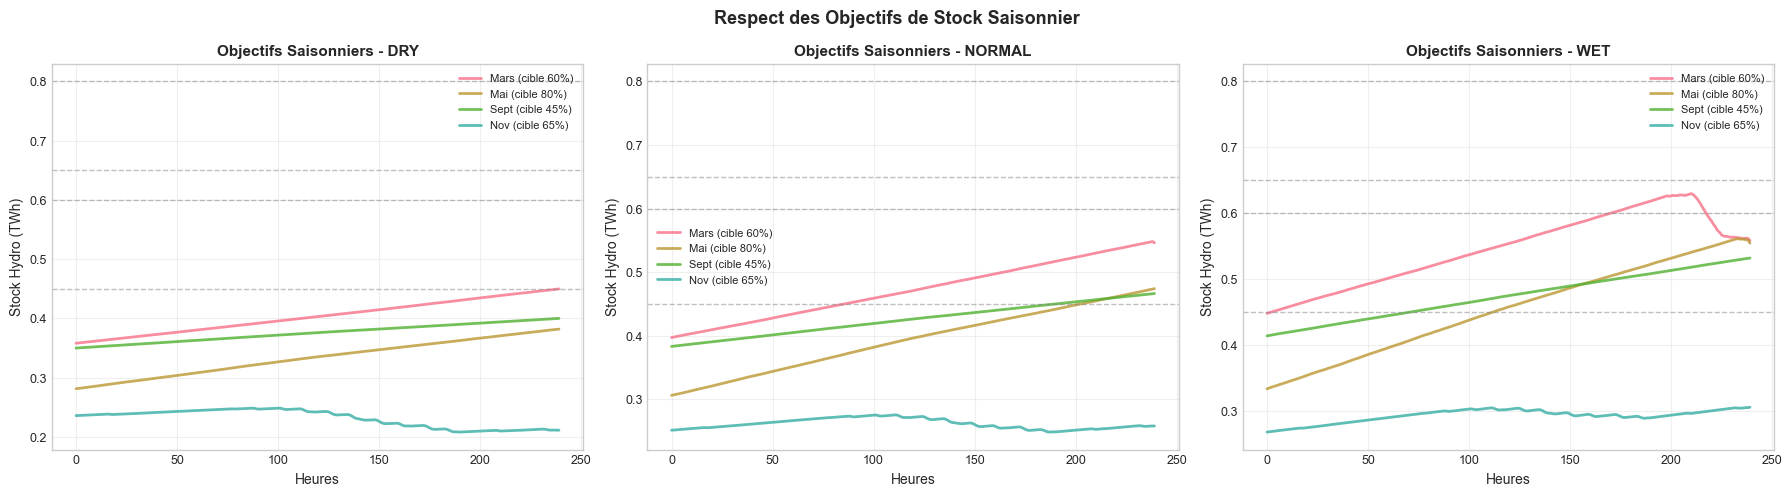

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

seasons_info = [
    ("fin_mars", 2041, 2280, 60, "Mars"),
    ("fin_mai", 3505, 3744, 80, "Mai"),
    ("fin_septembre", 6433, 6672, 45, "Sept"),
    ("fin_novembre", 7921, 8160, 65, "Nov")
]

colors = {'dry': '#E74C3C', 'normal': '#3498DB', 'wet': '#27AE60'}

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    for season_name, start_h, end_h, target_pct, month in seasons_info:
        # Utiliser l'index à la place de hour_global
        df_season = df[(df.index >= start_h) & (df.index <= end_h)]
        
        stock_twh = df_season['stock_hydro'] / 1e6
        target_twh = (target_pct / 100) * 1.0
        slack_season = df_season['slack_seasonal'].sum() if 'slack_seasonal' in df.columns else 0
        
        ax.plot(range(len(df_season)), stock_twh, label=f'{month} (cible {target_pct}%)', linewidth=2, alpha=0.8)
        ax.axhline(y=target_twh, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_title(f'Objectifs Saisonniers - {scenario.upper()}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Stock Hydro (TWh)')
    ax.set_xlabel('Heures')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Respect des Objectifs de Stock Saisonnier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

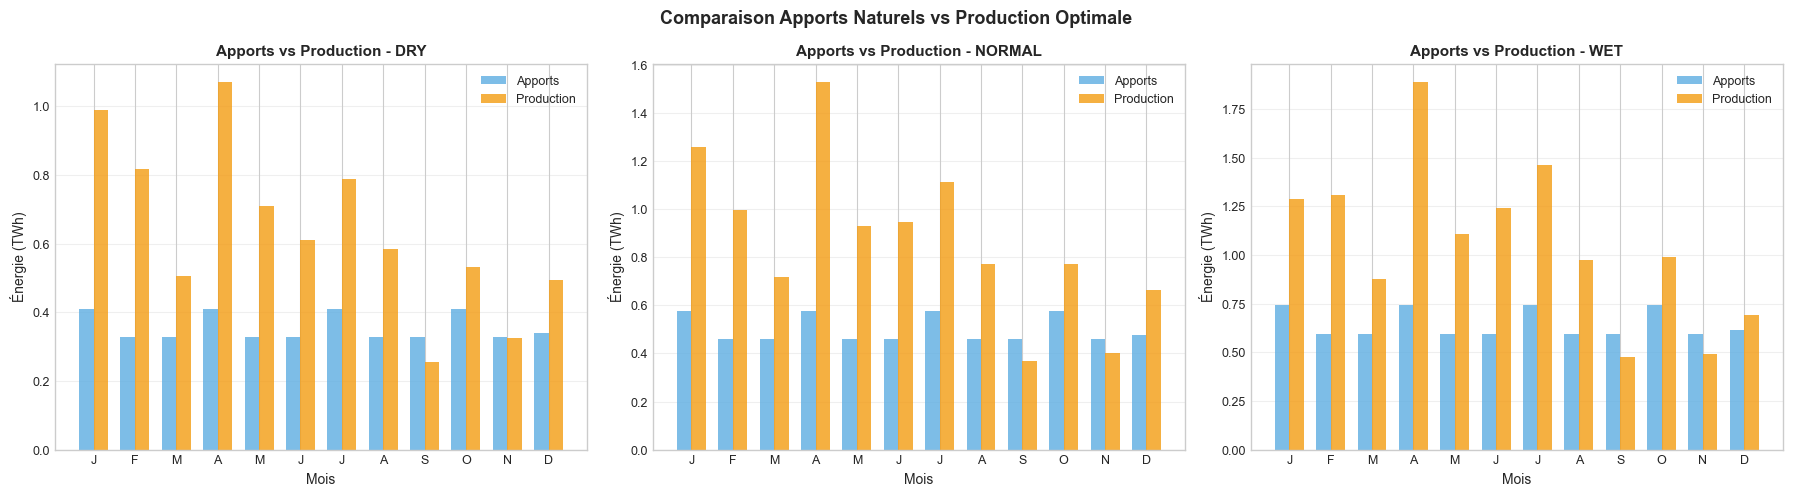

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    ax = axes[idx]
    
    # Apports mensuels
    monthly_inflows = (df.groupby('month')['inflows_lac'].sum() + df.groupby('month')['inflows_fdl'].sum()) / 1e6
    # Production mensuels
    monthly_production = (df.groupby('month')['Phy_lac'].sum() + df.groupby('month')['Phy_fdl'].sum()) / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    
    ax.bar(x - width/2, monthly_inflows, width, label='Apports', color='#5DADE2', alpha=0.8)
    ax.bar(x + width/2, monthly_production, width, label='Production', color='#F39C12', alpha=0.8)
    
    ax.set_title(f'Apports vs Production - {scenario.upper()}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Énergie (TWh)')
    ax.set_xlabel('Mois')
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison Apports Naturels vs Production Optimale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

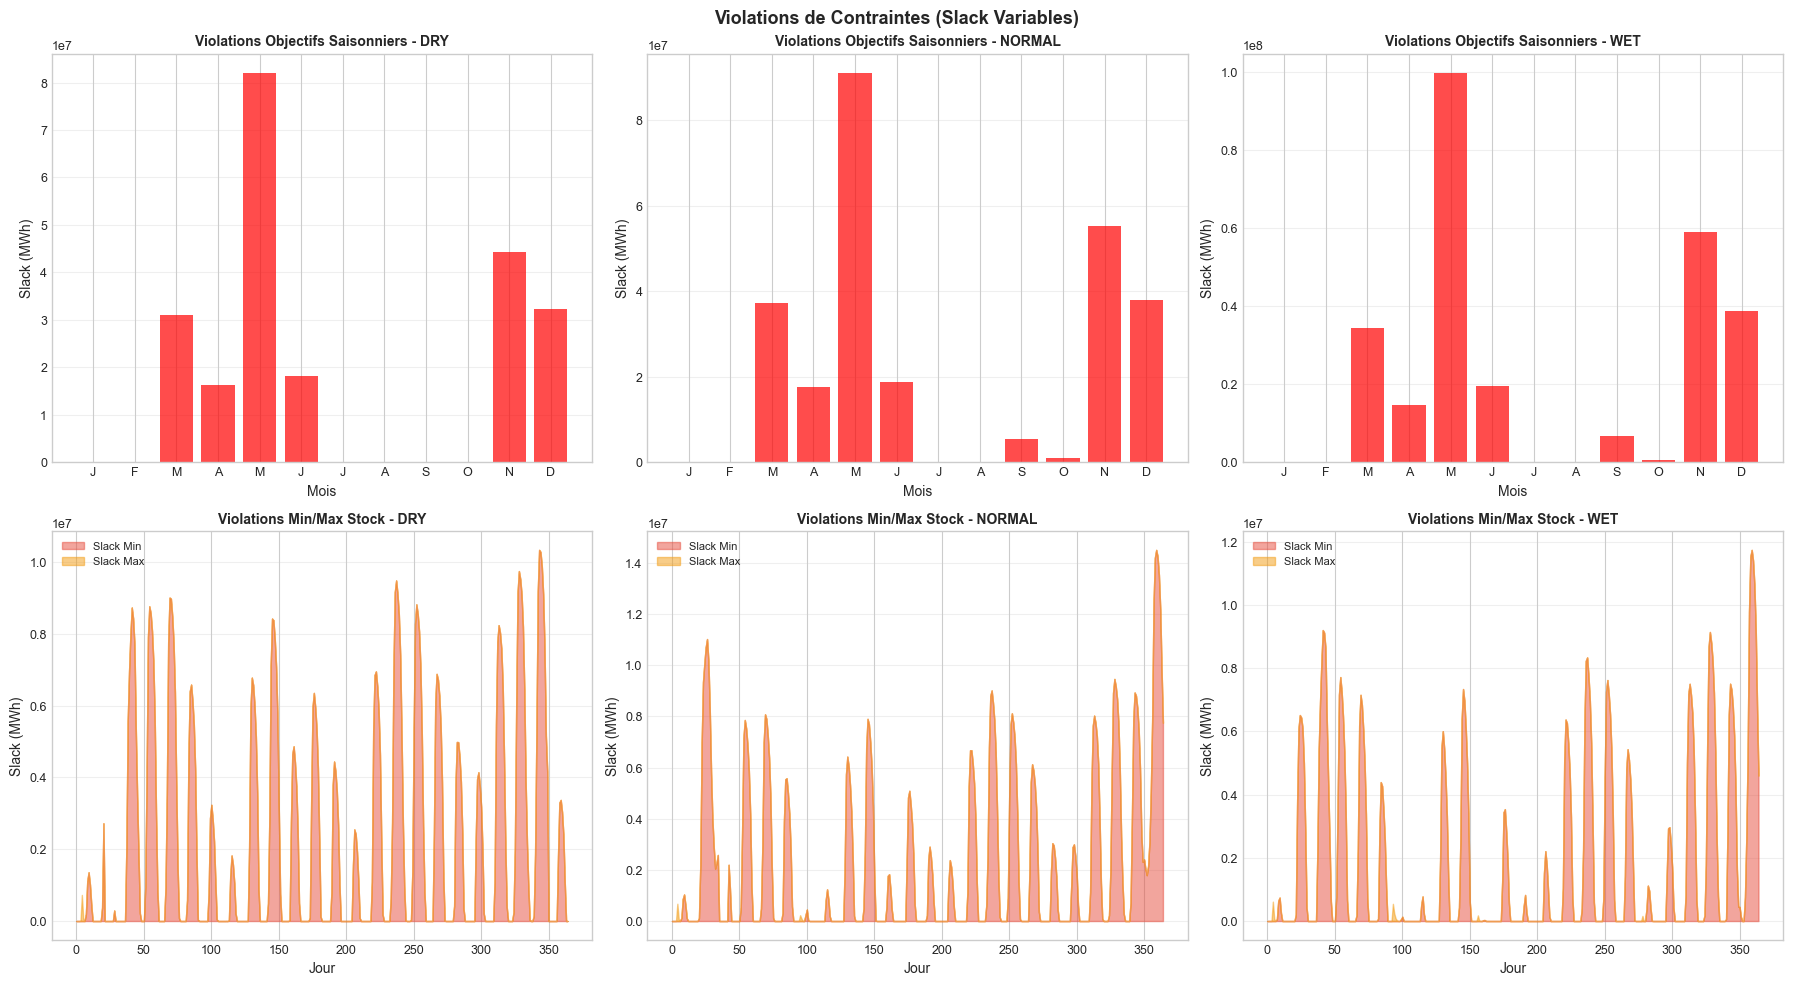


📊 RÉSUMÉ VIOLATIONS CONTRAINTES

DRY :
  Slack saisonnier total : 223.8756 TWh
  Slack min stock total  : 860.5165 TWh
  Slack max stock total  : 0.8157 TWh
  ⚠️  Violations détectées - À vérifier (1085.2078 TWh total)

NORMAL :
  Slack saisonnier total : 264.2426 TWh
  Slack min stock total  : 836.5046 TWh
  Slack max stock total  : 1.0822 TWh
  ⚠️  Violations détectées - À vérifier (1101.8294 TWh total)

WET :
  Slack saisonnier total : 272.9891 TWh
  Slack min stock total  : 690.3020 TWh
  Slack max stock total  : 1.9227 TWh
  ⚠️  Violations détectées - À vérifier (965.2138 TWh total)


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scenarios = ['dry', 'normal', 'wet']

for idx, scenario in enumerate(scenarios):
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # Slack saisonnier
    ax = axes[0, idx]
    if 'slack_seasonal' in df.columns:
        slack_seasonal_monthly = df.groupby('month')['slack_seasonal'].sum()
    else:
        slack_seasonal_monthly = pd.Series([0] * 12)
    
    x = np.arange(1, 13)
    colors_slack = ['red' if v > 0 else 'green' for v in slack_seasonal_monthly]
    ax.bar(x, slack_seasonal_monthly, color=colors_slack, alpha=0.7)
    ax.set_title(f'Violations Objectifs Saisonniers - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Slack (MWh)')
    ax.set_xlabel('Mois')
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Slack min/max stock
    ax = axes[1, idx]
    if 'slack_stock_min' in df.columns and 'slack_stock_max' in df.columns:
        slack_min_daily = df.groupby(df.index // 24)['slack_stock_min'].sum()
        slack_max_daily = df.groupby(df.index // 24)['slack_stock_max'].sum()
        
        days = np.arange(len(slack_min_daily))
        ax.fill_between(days, 0, slack_min_daily, alpha=0.5, color='#E74C3C', label='Slack Min')
        ax.fill_between(days, slack_min_daily, slack_min_daily + slack_max_daily, alpha=0.5, color='#F39C12', label='Slack Max')
        ax.set_title(f'Violations Min/Max Stock - {scenario.upper()}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Slack (MWh)')
        ax.set_xlabel('Jour')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Colonnes slack non disponibles', ha='center', va='center', transform=ax.transAxes)
    
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Violations de Contraintes (Slack Variables)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé violations
print("\n" + "="*80)
print("📊 RÉSUMÉ VIOLATIONS CONTRAINTES")
print("="*80)
for scenario in scenarios:
    if scenario not in results:
        continue
    df = results[scenario]
    
    total_slack_seasonal = df['slack_seasonal'].sum() if 'slack_seasonal' in df.columns else 0
    total_slack_min = df['slack_stock_min'].sum() if 'slack_stock_min' in df.columns else 0
    total_slack_max = df['slack_stock_max'].sum() if 'slack_stock_max' in df.columns else 0
    
    print(f"\n{scenario.upper()} :")
    print(f"  Slack saisonnier total : {total_slack_seasonal/1e6:.4f} TWh")
    print(f"  Slack min stock total  : {total_slack_min/1e6:.4f} TWh")
    print(f"  Slack max stock total  : {total_slack_max/1e6:.4f} TWh")
    total = total_slack_seasonal + total_slack_min + total_slack_max
    if total < 1:
        print(f"  ✅ Excellent - Contraintes bien respectées")
    else:
        print(f"  ⚠️  Violations détectées - À vérifier ({total/1e6:.4f} TWh total)")

KeyError: 'hour_global'

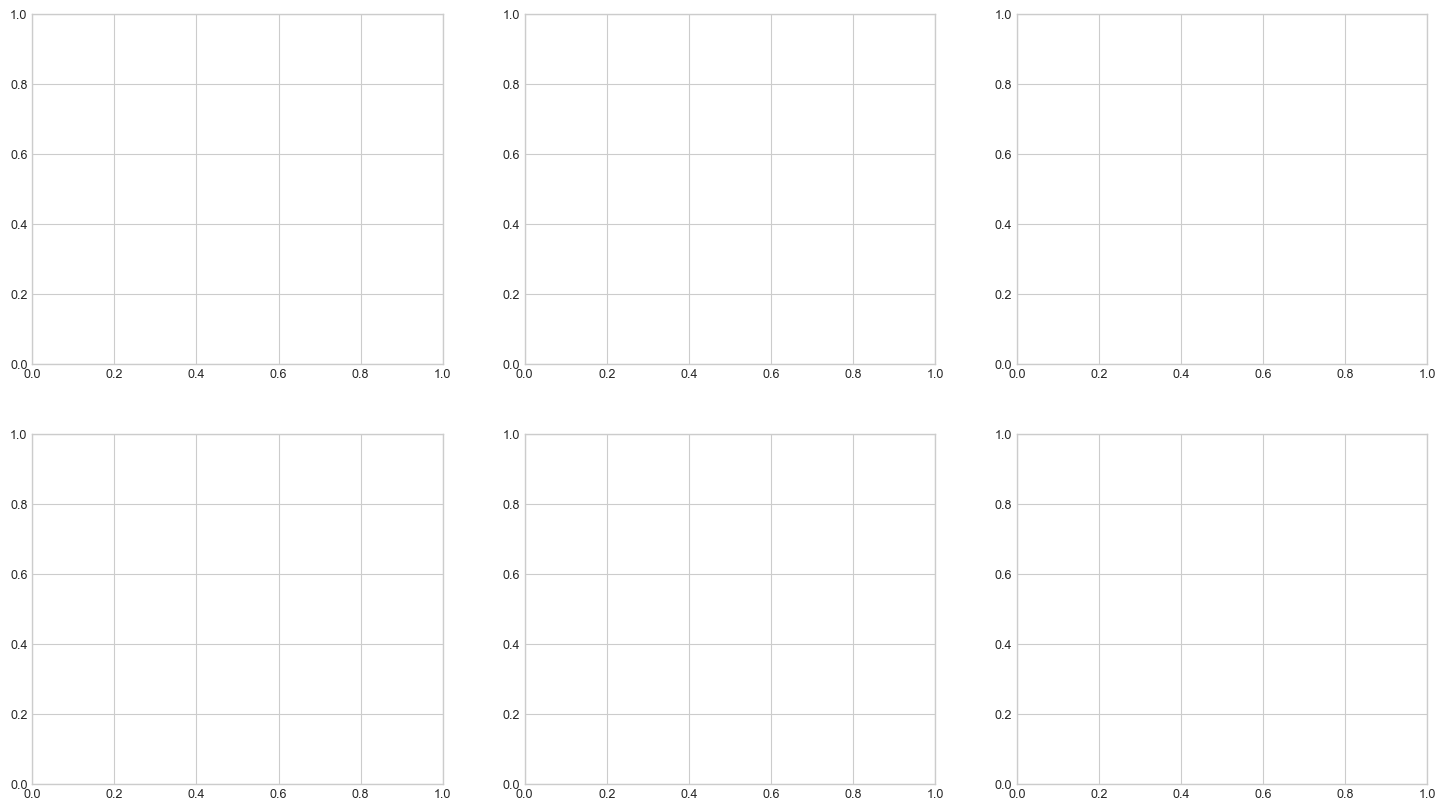

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    
    df = results[scenario]
    
    # Coûts journaliers
    ax = axes[0, idx]
    daily_cost_thermal = df.groupby(df['hour_global'] // 24)['cost_thermal_hour'].sum() / 1e6
    daily_cost_STEP = df.groupby(df['hour_global'] // 24)['cost_STEP_hour'].sum() / 1e6
    daily_cost_spill = df.groupby(df['hour_global'] // 24)['cost_spill_hour'].sum() / 1e6
    
    days = np.arange(len(daily_cost_thermal))
    ax.plot(days, daily_cost_thermal, label='Thermique', linewidth=2, color='#E74C3C')
    ax.plot(days, daily_cost_STEP, label='STEP', linewidth=2, color='#3498DB')
    ax.plot(days, daily_cost_spill, label='Spill', linewidth=2, color='#27AE60')
    
    ax.set_title(f'Coûts Hydrauliques Quotidiens - {scenario.upper()}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Coût (M€)')
    ax.set_xlabel('Jour')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Distribution coûts annuels
    ax = axes[1, idx]
    total_thermal = daily_cost_thermal.sum()
    total_STEP = daily_cost_STEP.sum()
    total_spill = daily_cost_spill.sum()
    total_unserved = (df['cost_unserved_hour'].sum() / 1e6)
    
    costs = [total_thermal, total_STEP, total_spill, total_unserved]
    labels = ['Thermique', 'STEP', 'Spill', 'Défaillance']
    colors_pie = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6']
    
    wedges, texts, autotexts = ax.pie(costs, labels=labels, autopct='%1.1f%%', 
                                        colors=colors_pie, startangle=90)
    ax.set_title(f'Répartition Coûts Annuels - {scenario.upper()}\nTotal: {sum(costs):.1f} M€', 
                 fontweight='bold', fontsize=10)

plt.suptitle('Analyse Coûts Hydrauliques et STEP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé coûts
print("\n" + "="*80)
print("💰 RÉSUMÉ COÛTS HYDRAULIQUES")
print("="*80)
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    total_thermal = (df['cost_thermal_hour'].sum() / 1e6)
    total_STEP = (df['cost_STEP_hour'].sum() / 1e6)
    total_spill = (df['cost_spill_hour'].sum() / 1e6)
    total_unserved = (df['cost_unserved_hour'].sum() / 1e6)
    
    print(f"\n{scenario.upper()} (Annuel) :")
    print(f"  Coût thermique  : {total_thermal:8.1f} M€")
    print(f"  Coût STEP       : {total_STEP:8.1f} M€")
    print(f"  Coût spill      : {total_spill:8.1f} M€")
    print(f"  Coût défaillance: {total_unserved:8.1f} M€")
    print(f"  ─────────────────────────")
    print(f"  TOTAL           : {total_thermal + total_STEP + total_spill + total_unserved:8.1f} M€")

---

## 💧 Hydraulique Approfondie

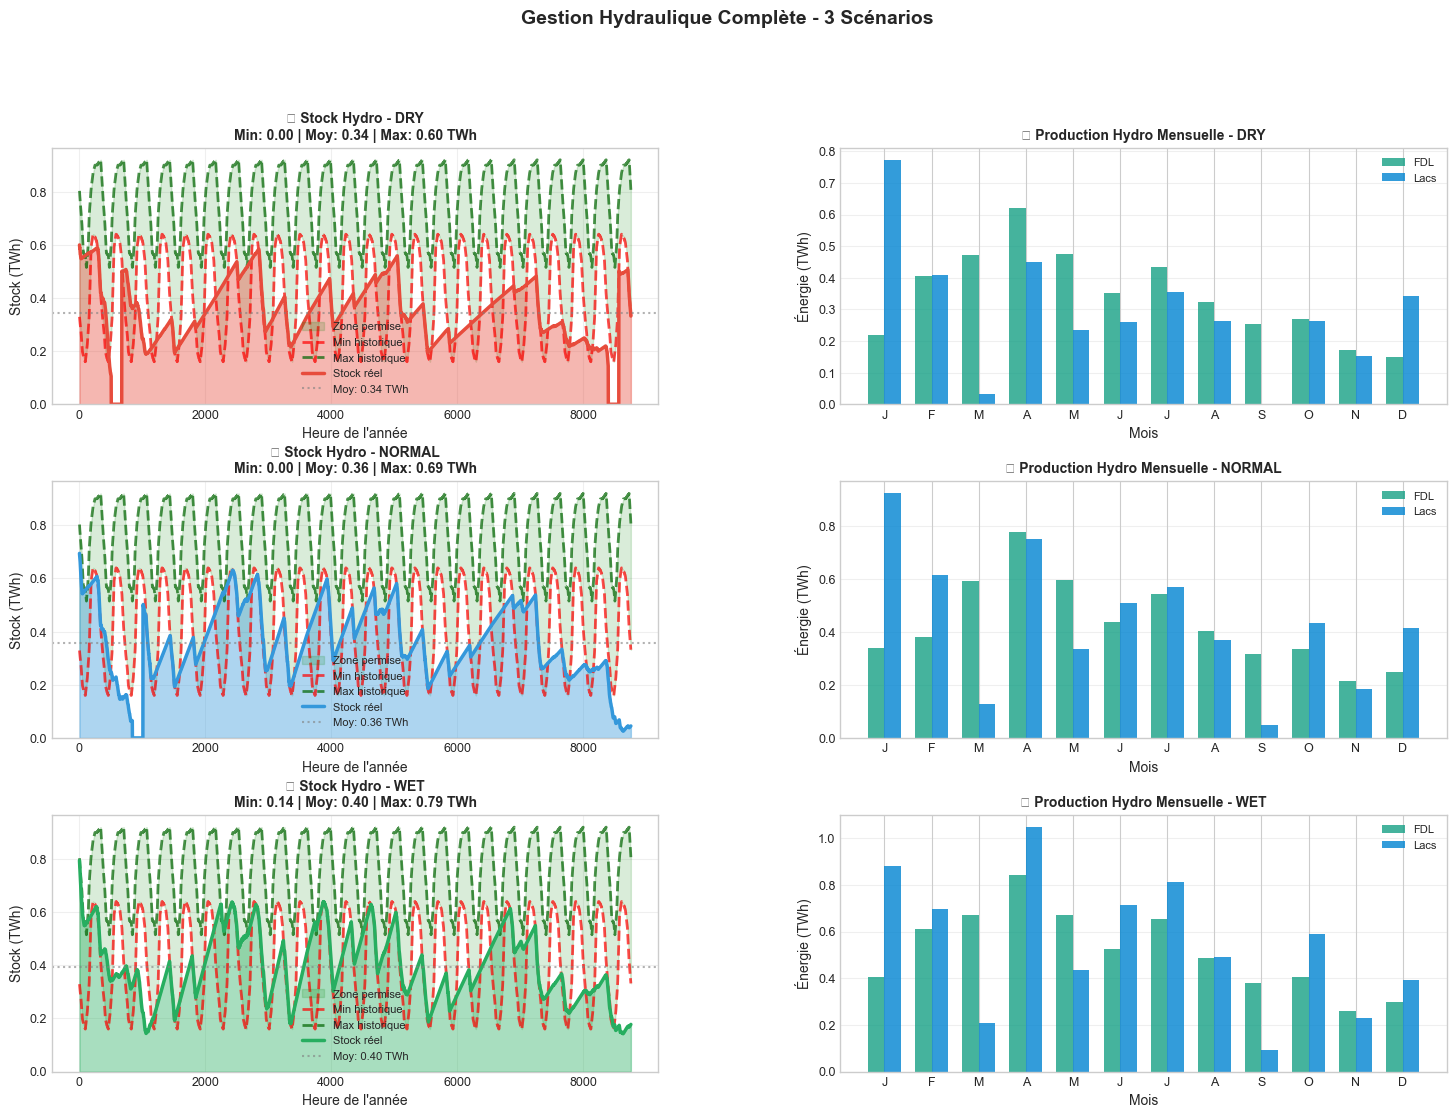

In [11]:
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results:
        continue
    df = results[scenario]
    
    # Stock hydraulique avec limites
    ax = fig.add_subplot(gs[idx, 0])
    stock_twh = df['stock_hydro'] / 1e6
    stock_min_twh = df['stock_hydro_min'] / 1e6
    stock_max_twh = df['stock_hydro_max'] / 1e6
    
    # Remplissage zone permise
    ax.fill_between(range(len(df)), stock_min_twh, stock_max_twh, alpha=0.15, color='green', label='Zone permise')
    
    # Limites min/max
    ax.plot(stock_min_twh, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Min historique')
    ax.plot(stock_max_twh, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='Max historique')
    
    # Stock actuel
    ax.fill_between(range(len(df)), 0, stock_twh, alpha=0.4, color=colors_scenario[scenario])
    ax.plot(stock_twh, color=colors_scenario[scenario], linewidth=2.5, label='Stock réel')
    
    # Statistiques
    ax.axhline(y=stock_twh.mean(), color='gray', linestyle=':', alpha=0.6, linewidth=1.5, label=f'Moy: {stock_twh.mean():.2f} TWh')
    
    ax.set_title(f"💧 Stock Hydro - {scenario.upper()}\nMin: {stock_twh.min():.2f} | Moy: {stock_twh.mean():.2f} | Max: {stock_twh.max():.2f} TWh",
                fontweight='bold', fontsize=10)
    ax.set_ylabel('Stock (TWh)')
    ax.set_xlabel('Heure de l\'année')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    
    # Production hydro mensuelle
    ax = fig.add_subplot(gs[idx, 1])
    monthly_fdl = df.groupby('month')['Phy_fdl'].sum() / 1e6
    monthly_lac = df.groupby('month')['Phy_lac'].sum() / 1e6
    
    x = np.arange(1, 13)
    width = 0.35
    ax.bar(x - width/2, monthly_fdl, width, label='FDL', color='#16A085', alpha=0.8)
    ax.bar(x + width/2, monthly_lac, width, label='Lacs', color='#0084D1', alpha=0.8)
    
    ax.set_title(f"⚡ Production Hydro Mensuelle - {scenario.upper()}", fontweight='bold', fontsize=10)
    ax.set_ylabel('Énergie (TWh)')
    ax.set_xlabel('Mois')
    ax.set_xticks(x)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Gestion Hydraulique Complète - 3 Scénarios', fontsize=14, fontweight='bold', y=0.995)
plt.show()

---
## Vérification Durées Minimales de Fonctionnement

In [12]:
print("=" * 100)
print("🔍 VÉRIFICATION DURÉES MINIMALES DE FONCTIONNEMENT (DMIN)")
print("=" * 100)

# Dictionnaire avec les dmin des unités (à adapter selon ton code)
dmin_units = {
    'Nucléaire': 6,      # Dmin en heures
    'charbon': 4,
    'CCG gaz': 2,
    'TAC gaz': 1,
    'cogénération gaz': 2,
    'fioul': 1
}

# Colonnes UC par type
uc_columns = {
    'Nucléaire': 'UC_nuc',
    'charbon': 'UC_charbon',
    'CCG gaz': 'UC_ccg',
    'TAC gaz': 'UC_tac',
    'cogénération gaz': 'UC_cogen',
    'fioul': 'UC_fioul'
}

violations = {}

for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    
    print(f"\n{'─' * 100}")
    print(f"SCÉNARIO : {scenario.upper()}")
    print(f"{'─' * 100}")
    
    df = results[scenario]
    violations[scenario] = []
    
    for gen_type, dmin in dmin_units.items():
        if dmin <= 0 or uc_columns[gen_type] not in df.columns:
            continue
        
        uc_col = uc_columns[gen_type]
        uc_data = df[uc_col].values
        
        violations_count = 0
        violation_details = []
        
        # Parcourir le signal UC et chercher des démarrages trop courts
        i = 0
        while i < len(uc_data):
            # Cherche un démarrage (0→1)
            if i > 0 and uc_data[i] == 1 and uc_data[i-1] == 0:
                # Compte combien de temps reste allumée
                duration = 0
                j = i
                while j < len(uc_data) and uc_data[j] == 1:
                    duration += 1
                    j += 1
                
                # Vérifie si durée < dmin
                if 0 < duration < dmin:
                    violations_count += 1
                    violation_details.append(f"  Heure {i+1}: démarrage, durée {duration}h < dmin {dmin}h ❌")
                
                i = j  # Saute au prochain changement
            else:
                i += 1
        
        if violations_count > 0:
            print(f"\n⚠️  {gen_type.upper()} (dmin={dmin}h) : {violations_count} VIOLATION(S)")
            for detail in violation_details[:5]:  # Affiche max 5 violations
                print(detail)
            if len(violation_details) > 5:
                print(f"  ... et {len(violation_details) - 5} autres violations")
            violations[scenario].append((gen_type, violations_count))
        else:
            print(f"✅ {gen_type.upper()} (dmin={dmin}h) : Contrainte RESPECTÉE")

print(f"\n{'=' * 100}")
print("📊 RÉSUMÉ VIOLATIONS")
print(f"{'=' * 100}")

has_violations = False
for scenario, viols in violations.items():
    if viols:
        has_violations = True
        print(f"\n❌ {scenario.upper()} : {sum(v[1] for v in viols)} violation(s) au total")
        for gen_type, count in viols:
            print(f"   - {gen_type}: {count} violation(s)")

if not has_violations:
    print("\n✅ EXCELLENT ! Aucune violation détectée - Les dmin sont respectées pour tous les scénarios !")

🔍 VÉRIFICATION DURÉES MINIMALES DE FONCTIONNEMENT (DMIN)

────────────────────────────────────────────────────────────────────────────────────────────────────
SCÉNARIO : DRY
────────────────────────────────────────────────────────────────────────────────────────────────────

⚠️  NUCLÉAIRE (dmin=6h) : 1 VIOLATION(S)
  Heure 4098: démarrage, durée 1h < dmin 6h ❌

⚠️  CHARBON (dmin=4h) : 47 VIOLATION(S)
  Heure 22: démarrage, durée 2h < dmin 4h ❌
  Heure 673: démarrage, durée 2h < dmin 4h ❌
  Heure 870: démarrage, durée 1h < dmin 4h ❌
  Heure 1947: démarrage, durée 2h < dmin 4h ❌
  Heure 1974: démarrage, durée 1h < dmin 4h ❌
  ... et 42 autres violations

⚠️  CCG GAZ (dmin=2h) : 52 VIOLATION(S)
  Heure 1376: démarrage, durée 1h < dmin 2h ❌
  Heure 1962: démarrage, durée 1h < dmin 2h ❌
  Heure 2094: démarrage, durée 1h < dmin 2h ❌
  Heure 2106: démarrage, durée 1h < dmin 2h ❌
  Heure 2154: démarrage, durée 1h < dmin 2h ❌
  ... et 47 autres violations
✅ TAC GAZ (dmin=1h) : Contrainte RESPEC

---

## 🔴 Défaillance

In [ ]:
def verify_balance(results_dict, scenario):
    """Vérifier l'équation bilan à chaque heure et calculer les défaillances réelles"""
    df = results_dict[scenario].copy()

    production_cols = ['P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul',
                       'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'Phy_fdl', 'Phy_lac']

    # Calcul du bilan
    df['production'] = df[production_cols].sum(axis=1)
    df['pdecharge_step'] = df['Pdecharge_STEP'] if 'Pdecharge_STEP' in df.columns else 0
    df['pcharge_step'] = df['Pcharge_STEP'] if 'Pcharge_STEP' in df.columns else 0

    df['supply'] = df['production'] + df['pdecharge_step']
    df['demand'] = df['load'] + df['pcharge_step']
    df['balance'] = df['supply'] - df['demand']

    # Calcul des défaillances réelles (balance < 0)
    df['real_Puns'] = df['balance'].clip(upper=0).abs()

    # Détection des anomalies
    tolerance = 1.0  # 1 MW de tolérance
    anomalies = df[abs(df['balance']) > tolerance]

    print(f"\n{'='*100}")
    print(f"VÉRIFICATION BILAN - Scénario {scenario.upper()}")
    print(f"{'='*100}\n")

    print(f"✅ Heures équilibrées (|balance| ≤ {tolerance} MW)  : {len(df) - len(anomalies):5} / {len(df)} ({100*(len(df) - len(anomalies))/len(df):.2f}%)")
    print(f"⚠️  Heures anomalies (|balance| > {tolerance} MW)   : {len(anomalies):5} / {len(df)} ({100*len(anomalies)/len(df):.2f}%)\n")

    if len(anomalies) > 0:
        print(f"🔴 ANOMALIES DÉTECTÉES :\n")
        print(f"{'Heure':>6} {'Month':>5} {'Load':>8} {'Prod':>8} {'STEP↓':>8} {'Supply':>8} {'Demand':>8} {'Balance':>10} {'Type':>12}")
        print(f"{'-'*100}")

        for idx, row in anomalies.iterrows():
            balance = row['balance']
            type_anomaly = "EXCÉDENT" if balance > tolerance else "DÉFAILLANCE"

            print(f"{row['hour']:6.0f} {row['month']:5.0f} {row['load']:8.0f} {row['production']:8.0f} " +
                  f"{row['pdecharge_step']:8.0f} {row['supply']:8.0f} {row['demand']:8.0f} {balance:10.2f} {type_anomaly:>12}")

        print(f"\n📊 STATISTIQUES ANOMALIES :\n")
        defaillances = anomalies[anomalies['balance'] < -tolerance]
        excedents = anomalies[anomalies['balance'] > tolerance]

        if len(defaillances) > 0:
            print(f"🔴 DÉFAILLANCES ({len(defaillances)} heures):")
            print(f"   Min    : {defaillances['balance'].min():.2f} MW")
            print(f"   Moy    : {defaillances['balance'].mean():.2f} MW")
            print(f"   Max    : {defaillances['balance'].max():.2f} MW")
            print(f"   Total  : {defaillances['balance'].sum()/1e6:.3f} TWh")
            print(f"   Total réel Puns : {defaillances['real_Puns'].sum()/1e6:.6f} TWh\n")

        if len(excedents) > 0:
            print(f"🟢 EXCÉDENTS ({len(excedents)} heures):")
            print(f"   Min    : {excedents['balance'].min():.2f} MW")
            print(f"   Moy    : {excedents['balance'].mean():.2f} MW")
            print(f"   Max    : {excedents['balance'].max():.2f} MW")
            print(f"   Total  : {excedents['balance'].sum()/1e6:.3f} TWh\n")
    else:
        print(f"✅ BILAN PARFAIT - Toutes les heures équilibrées !\n")

    print(f"{'='*100}\n")

    return df

# Lancer la vérification pour chaque scénario
for scenario in ['dry', 'normal', 'wet']:
    if scenario in results:
        results[scenario] = verify_balance(results, scenario)



VÉRIFICATION BILAN - Scénario DRY

✅ Heures équilibrées (|balance| ≤ 1.0 MW)  :  8760 / 8760 (100.00%)
⚠️  Heures anomalies (|balance| > 1.0 MW)   :     0 / 8760 (0.00%)

✅ BILAN PARFAIT - Toutes les heures équilibrées !



VÉRIFICATION BILAN - Scénario NORMAL

✅ Heures équilibrées (|balance| ≤ 1.0 MW)  :  8592 / 8592 (100.00%)
⚠️  Heures anomalies (|balance| > 1.0 MW)   :     0 / 8592 (0.00%)

✅ BILAN PARFAIT - Toutes les heures équilibrées !



VÉRIFICATION BILAN - Scénario WET

✅ Heures équilibrées (|balance| ≤ 1.0 MW)  :  8760 / 8760 (100.00%)
⚠️  Heures anomalies (|balance| > 1.0 MW)   :     0 / 8760 (0.00%)

✅ BILAN PARFAIT - Toutes les heures équilibrées !




---

## ⚡Mix Électrique & Sources

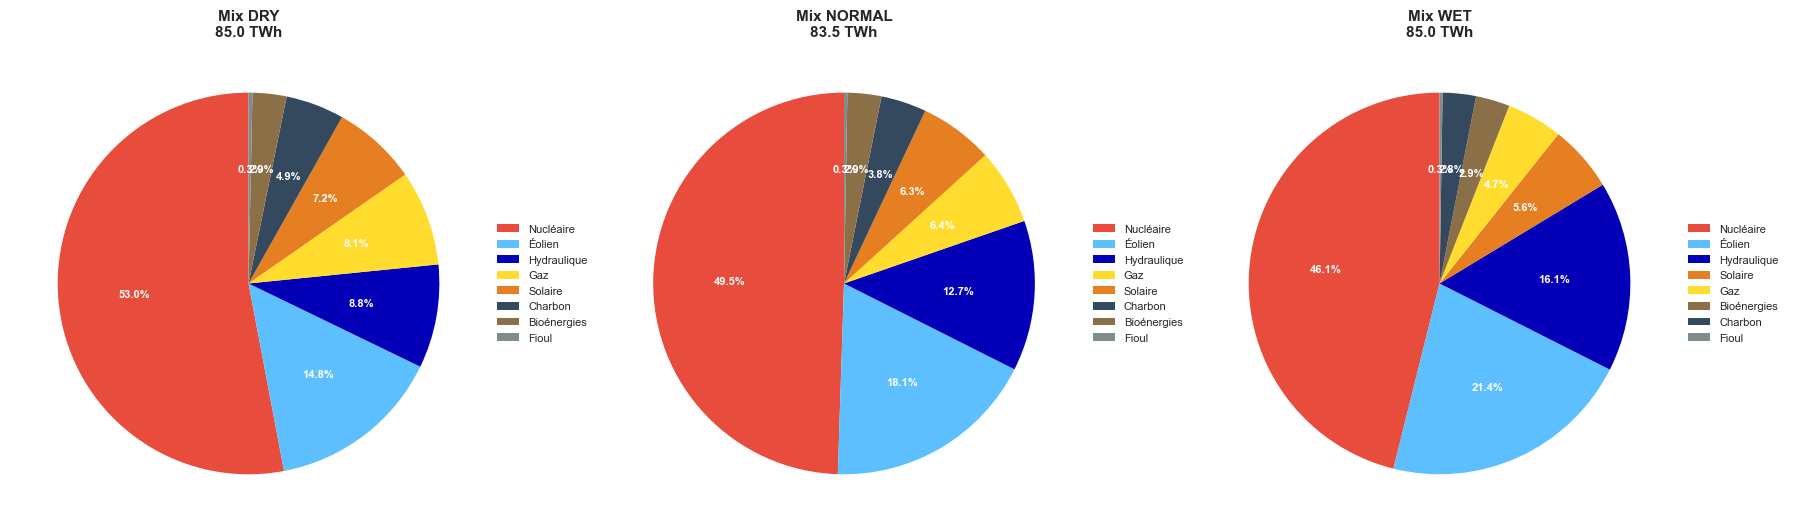

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, scenario in enumerate(['dry', 'normal', 'wet']):
    if scenario not in results: continue
    df = results[scenario]
    
    # Grouper par catégories avec couleurs
    prod_data = {
        'Nucléaire': (df['P_nuc'].sum()/1e6, colors_prod['P_nuc']),
        'Charbon': (df['P_charbon'].sum()/1e6, colors_prod['P_charbon']),
        'Gaz': ((df['P_ccg'].sum() + df['P_tac'].sum() + df['P_cogen'].sum())/1e6, colors_prod['P_ccg']),
        'Fioul': (df['P_fioul'].sum()/1e6, colors_prod['P_fioul']),
        'Éolien': (df['P_eolien'].sum()/1e6, colors_prod['P_eolien']),
        'Solaire': (df['P_solaire'].sum()/1e6, colors_prod['P_solaire']),
        'Hydraulique': ((df['Phy_fdl'].sum() + df['Phy_lac'].sum() + df['Pdecharge_STEP'].sum())/1e6, colors_prod['Phy_fdl']),
        'Bioénergies': ((df['P_dechets'].sum() + df['P_biomasse'].sum())/1e6, colors_prod['P_dechets'])
    }
    
    # Filtrer et trier
    prod_data = {k: v for k, v in prod_data.items() if v[0] > 0.1}
    prod_data = dict(sorted(prod_data.items(), key=lambda x: x[1][0], reverse=True))
    
    if prod_data:
        labels_f = list(prod_data.keys())
        prod_vals = [v[0] for v in prod_data.values()]
        colors_f = [v[1] for v in prod_data.values()]
        
        wedges, texts, autotexts = axes[idx].pie(prod_vals, colors=colors_f, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
        axes[idx].set_title(f'Mix {scenario.upper()}\n{sum(prod_vals):.1f} TWh', fontweight='bold')
        axes[idx].legend(wedges, labels_f, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)

plt.tight_layout()
plt.show()

---

## 📊 Analyse UC (Unit Commitment)

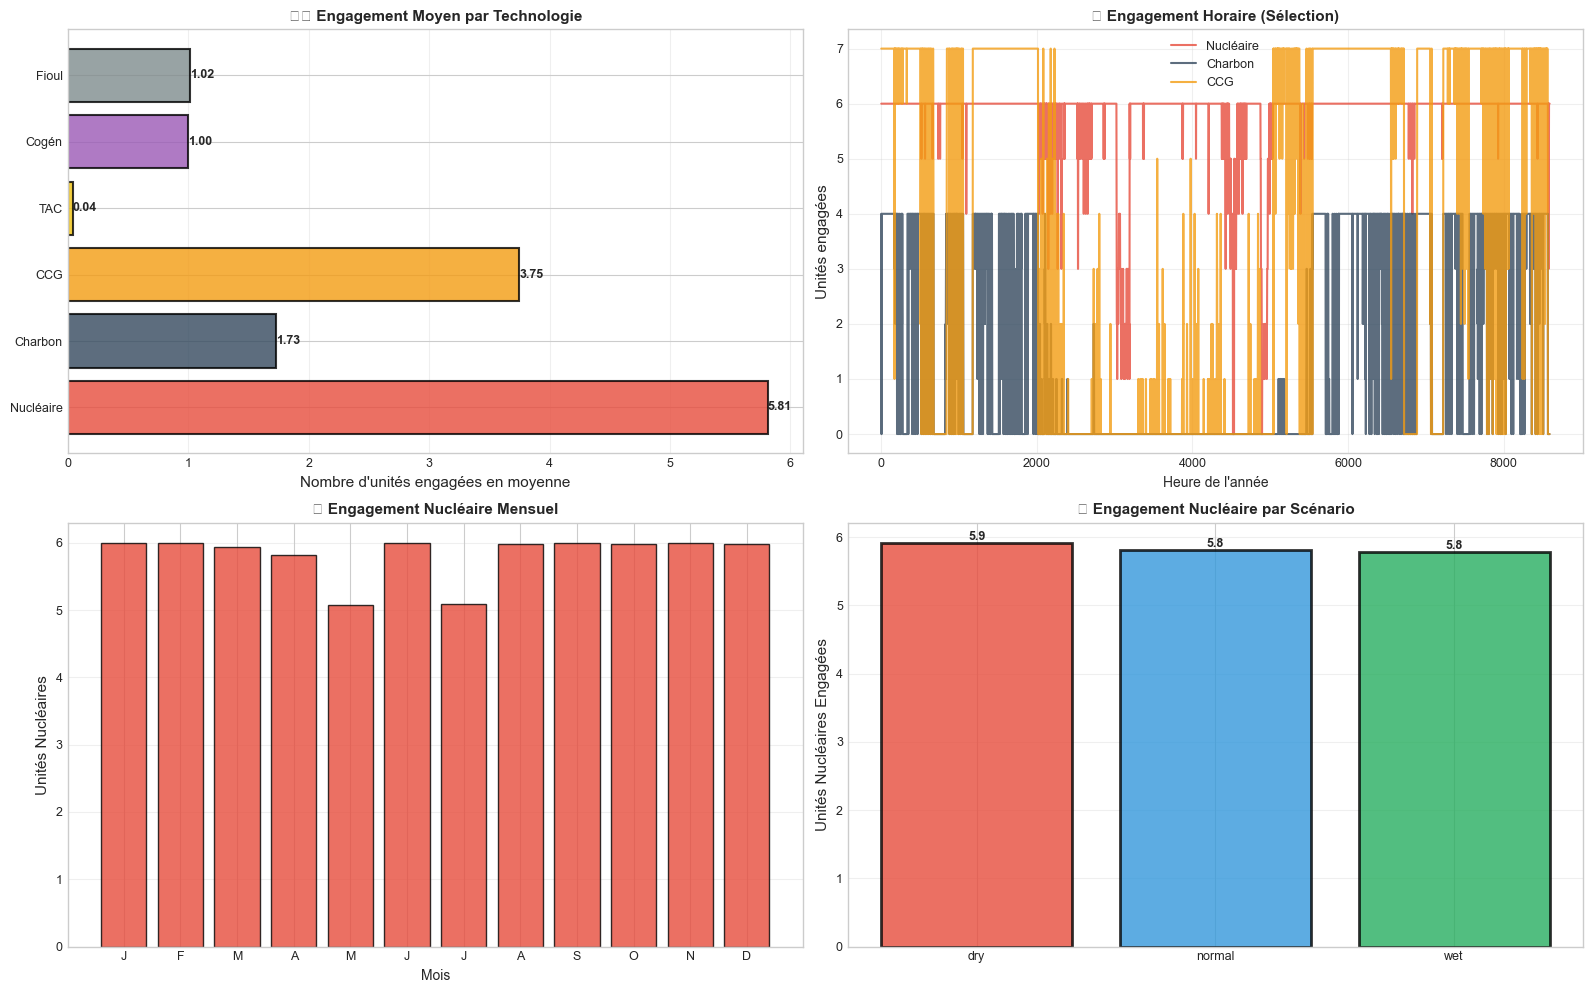

In [ ]:
df = results['normal']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Unités engagées moyennes
ax = axes[0, 0]
uc_cols = ['UC_nuc', 'UC_charbon', 'UC_ccg', 'UC_tac', 'UC_cogen', 'UC_fioul']
uc_labels = ['Nucléaire', 'Charbon', 'CCG', 'TAC', 'Cogén', 'Fioul']
uc_means = [df[col].mean() for col in uc_cols if col in df.columns]

bars = ax.barh(uc_labels[:len(uc_means)], uc_means, color=['#E74C3C', '#34495E', '#F39C12', '#F1C40F', '#9B59B6', '#7F8C8D'][:len(uc_means)],
                alpha=0.8, edgecolor='black', linewidth=1.5)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'{width:.2f}', ha='left', va='center', fontweight='bold')

ax.set_xlabel('Nombre d\'unités engagées en moyenne', fontsize=11)
ax.set_title('⚙️ Engagement Moyen par Technologie', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Engagement horaire
ax = axes[0, 1]
for col, label, color in zip(uc_cols[:3], uc_labels[:3], ['#E74C3C', '#34495E', '#F39C12']):
    if col in df.columns:
        ax.plot(df[col], label=label, linewidth=1.5, color=color, alpha=0.8)

ax.set_ylabel('Unités engagées', fontsize=11)
ax.set_xlabel('Heure de l\'année')
ax.set_title('📈 Engagement Horaire (Sélection)', fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Engagement mensuel
ax = axes[1, 0]
monthly_engagement = df.groupby('month')[uc_cols[0]].mean()
ax.bar(range(1, 13), monthly_engagement, color='#E74C3C', alpha=0.8, edgecolor='black')
ax.set_ylabel('Unités Nucléaires', fontsize=11)
ax.set_xlabel('Mois')
ax.set_title('🔋 Engagement Nucléaire Mensuel', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax.grid(True, alpha=0.3, axis='y')

# Engagement par scénario
ax = axes[1, 1]
uc_scenarios = {s: results[s]['UC_nuc'].mean() for s in ['dry', 'normal', 'wet'] if s in results}
bars = ax.bar(uc_scenarios.keys(), uc_scenarios.values(),
               color=[colors_scenario[s] for s in uc_scenarios.keys()], alpha=0.8, edgecolor='black', linewidth=2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Unités Nucléaires Engagées', fontsize=11)
ax.set_title('🔋 Engagement Nucléaire par Scénario', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 🌪️ Production ENR Détaillée

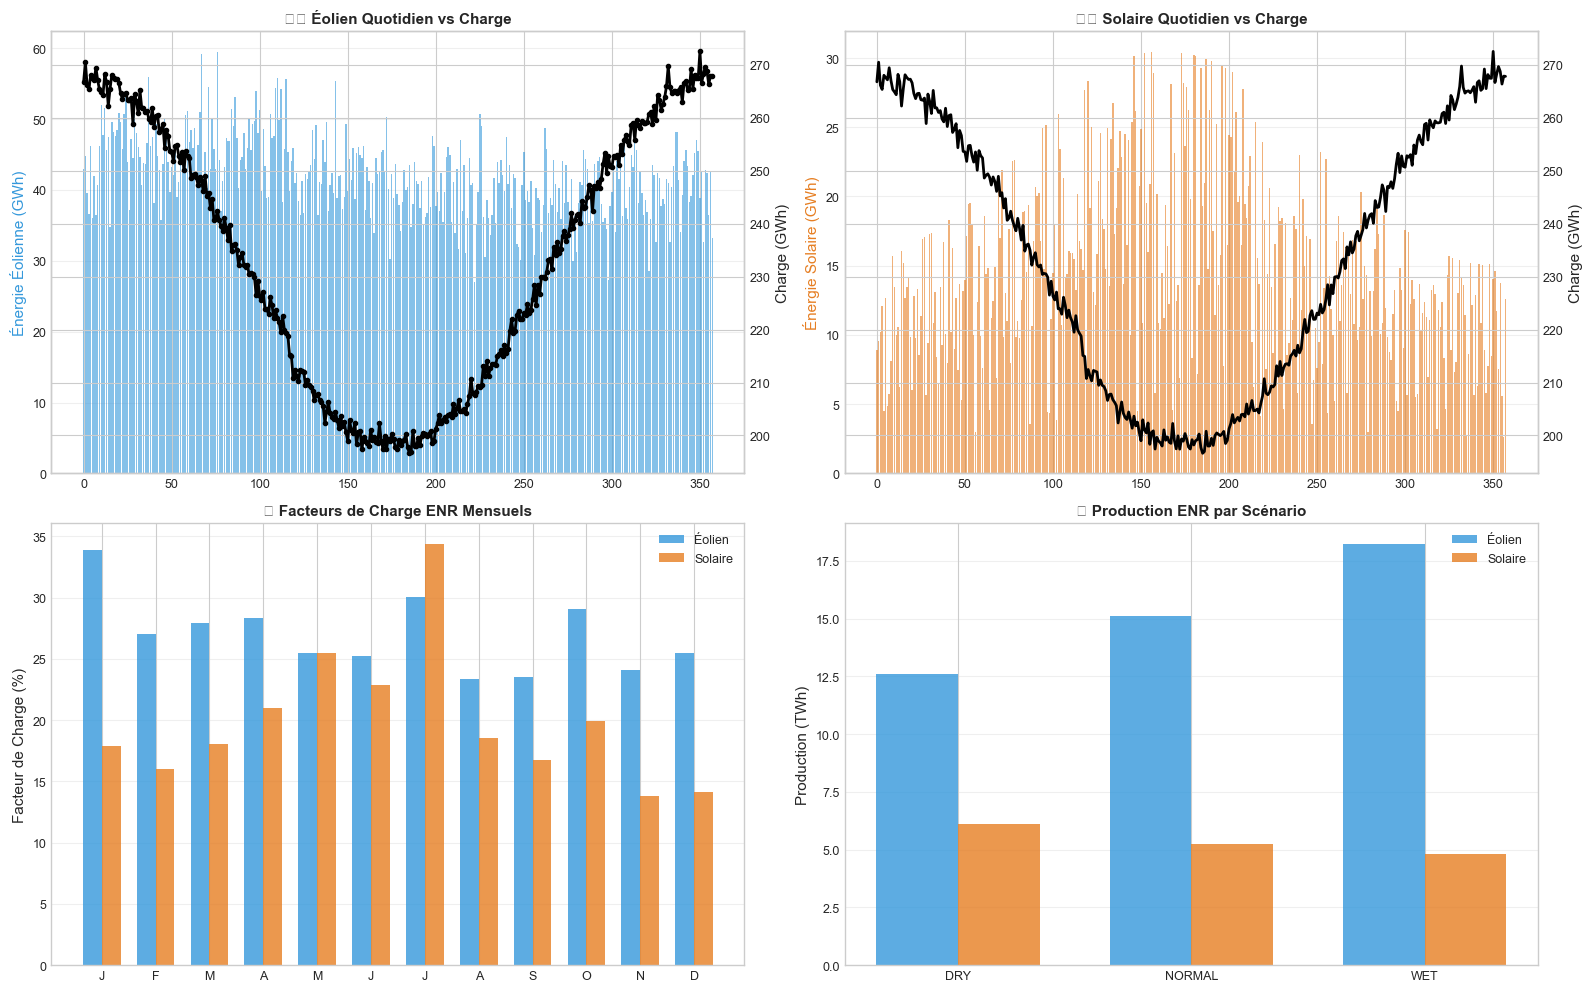

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df = results['normal']

# 1. Éolien vs Charge
ax = axes[0, 0]
daily_wind = df.groupby(df.index // 24)['P_eolien'].sum() / 1e3  # En GWh
daily_load = df.groupby(df.index // 24)['load'].sum() / 1e3
ax.bar(range(len(daily_wind)), daily_wind, alpha=0.6, label='Éolien', color='#3498DB')
ax2 = ax.twinx()
ax2.plot(daily_load, 'k-', linewidth=2, label='Charge', marker='o', markersize=3)
ax.set_ylabel('Énergie Éolienne (GWh)', color='#3498DB', fontsize=11)
ax2.set_ylabel('Charge (GWh)', fontsize=11)
ax.set_title('🌬️ Éolien Quotidien vs Charge', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Solaire vs Charge
ax = axes[0, 1]
daily_solar = df.groupby(df.index // 24)['P_solaire'].sum() / 1e3
ax.bar(range(len(daily_solar)), daily_solar, alpha=0.6, label='Solaire', color='#E67E22')
ax2 = ax.twinx()
ax2.plot(daily_load, 'k-', linewidth=2, label='Charge')
ax.set_ylabel('Énergie Solaire (GWh)', color='#E67E22', fontsize=11)
ax2.set_ylabel('Charge (GWh)', fontsize=11)
ax.set_title('☀️ Solaire Quotidien vs Charge', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3. Facteurs de charge mensuels
ax = axes[1, 0]
monthly_wind_cf = 100 * df.groupby('month')['P_eolien'].sum() / (6400 * 730)  # 6400 MW capacity
monthly_solar_cf = 100 * df.groupby('month')['P_solaire'].sum() / (3000 * 730)  # 3000 MW capacity

x = np.arange(1, 13)
width = 0.35
ax.bar(x - width/2, monthly_wind_cf, width, label='Éolien', color='#3498DB', alpha=0.8)
ax.bar(x + width/2, monthly_solar_cf, width, label='Solaire', color='#E67E22', alpha=0.8)
ax.set_ylabel('Facteur de Charge (%)', fontsize=11)
ax.set_title('📊 Facteurs de Charge ENR Mensuels', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 4. Comparaison ENR par scénario
ax = axes[1, 1]
enr_by_scenario = {}
for scenario in ['dry', 'normal', 'wet']:
    if scenario in results:
        df_s = results[scenario]
        wind_twh = df_s['P_eolien'].sum() / 1e6
        solar_twh = df_s['P_solaire'].sum() / 1e6
        enr_by_scenario[scenario] = (wind_twh, solar_twh)

scenarios = list(enr_by_scenario.keys())
wind_vals = [v[0] for v in enr_by_scenario.values()]
solar_vals = [v[1] for v in enr_by_scenario.values()]

x = np.arange(len(scenarios))
width = 0.35
ax.bar(x - width/2, wind_vals, width, label='Éolien', color='#3498DB', alpha=0.8)
ax.bar(x + width/2, solar_vals, width, label='Solaire', color='#E67E22', alpha=0.8)
ax.set_ylabel('Production (TWh)', fontsize=11)
ax.set_title('🌍 Production ENR par Scénario', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in scenarios])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 🔄 Semaines Complètes - Profils Détaillés

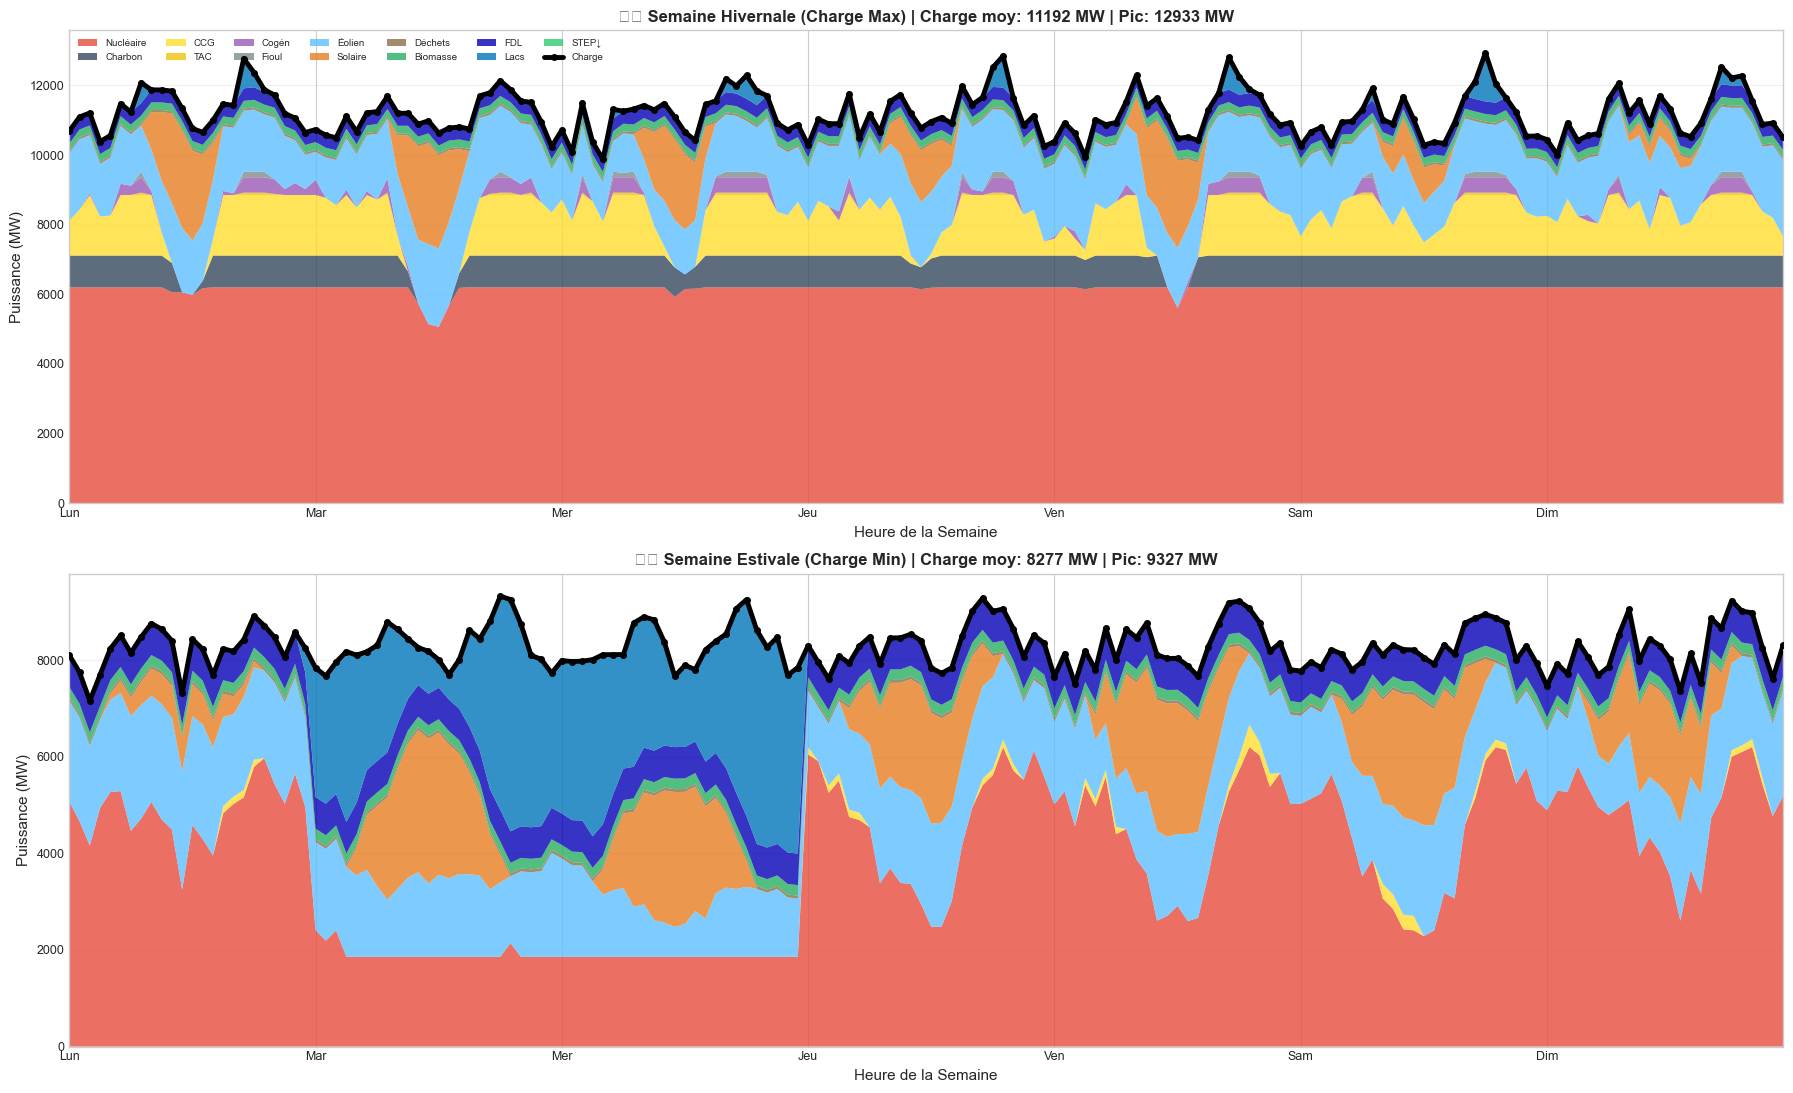

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Sélection des semaines
winter_months = df[df['month'].isin([1, 2, 12])]
# Trouver le jour avec la charge maximale
winter_days = winter_months.groupby(winter_months.index // 24)['load'].mean()
winter_day_start = winter_days.idxmax() * 24  # Début du jour avec la charge maximale

# S'assurer que la semaine est dans les limites de df
if winter_day_start + 168 <= len(df):
    winter_week = df.iloc[winter_day_start:winter_day_start + 168]
else:
    # Si la semaine dépasse, prendre la semaine précédente
    winter_week = df.iloc[winter_day_start - 168:winter_day_start]


summer_months = df[df['month'].isin([6, 7, 8])]
summer_week_start = summer_months.nsmallest(1, 'load').index[0]
summer_week_start = (summer_week_start // 24) * 24  # Début du jour
summer_week = df.iloc[summer_week_start:summer_week_start + 168]

# Vérification de la longueur des données
assert len(winter_week) == 168, f"La semaine hivernale ne contient que {len(winter_week)} heures au lieu de 168."
assert len(summer_week) == 168, f"La semaine estivale ne contient que {len(summer_week)} heures au lieu de 168."

# Création des graphiques
fig, axes = plt.subplots(2, 1, figsize=(18, 11))

production_cols = ['P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul',
                   'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'Phy_fdl', 'Phy_lac']

for idx, (data, title) in enumerate([(winter_week, '❄️ Semaine Hivernale (Charge Max)'),
                                      (summer_week, '☀️ Semaine Estivale (Charge Min)')]):
    ax = axes[idx]

    if len(data) == 0:
        print(f"⚠️ Pas de données pour {title}")
        continue

    # Réinitialiser l'index pour stackplot
    data_reset = data.reset_index(drop=True)

    # Ajouter STEP décharge à la production
    data_with_step = data_reset.copy()
    production_cols_avec_step = production_cols + ['Pdecharge_STEP']

    # Area plot avec STEP
    ax.stackplot(range(len(data_with_step)),
                 *[data_with_step[col] for col in production_cols_avec_step if col in data_with_step.columns],
                 labels=['Nucléaire', 'Charbon', 'CCG', 'TAC', 'Cogén', 'Fioul',
                        'Éolien', 'Solaire', 'Déchets', 'Biomasse', 'FDL', 'Lacs', 'STEP↓'],
                 colors=[colors_prod.get(col, '#2ECC71' if col == 'Pdecharge_STEP' else '#999')
                        for col in production_cols_avec_step],
                 alpha=0.8)

    # Charge
    ax.plot(range(len(data_with_step)), data_with_step['load'], 'k-', linewidth=3.5,
            label='Charge', marker='o', markersize=4, zorder=10)

    charge_moy = data_with_step['load'].mean()
    charge_pic = data_with_step['load'].max()

    ax.set_title(f"{title} | Charge moy: {charge_moy:.0f} MW | Pic: {charge_pic:.0f} MW",
                fontsize=12, fontweight='bold')
    ax.set_ylabel('Puissance (MW)', fontsize=11)
    ax.set_xlabel('Heure de la Semaine', fontsize=11)
    ax.set_xticks(range(0, 168, 24))
    ax.set_xticklabels(['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlim(0, 167)  # Fenêtre fixée

    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[-14:],
                 ['Nucléaire', 'Charbon', 'CCG', 'TAC', 'Cogén', 'Fioul',
                  'Éolien', 'Solaire', 'Déchets', 'Biomasse', 'FDL', 'Lacs', 'STEP↓', 'Charge'],
                 loc='upper left', fontsize=7, ncol=7, framealpha=0.95)

plt.tight_layout()
plt.show()


---

## 📋 Tableau Récapitulatif Final

In [ ]:
print("\n" + "="*140)
print("SYNTHÈSE GLOBALE - EOD ZOOTOPIA")
print("="*140 + "\n")

summary_data = []
for scenario in ['dry', 'normal', 'wet']:
    if scenario not in results:
        continue
    df = results[scenario]
    
    prod_cols = ['P_nuc', 'P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul',
                 'P_eolien', 'P_solaire', 'P_dechets', 'P_biomasse', 'Phy_fdl', 'Phy_lac']
    
    row = {
        'Scénario': scenario.upper(),
        'Charge (TWh)': f"{df['load'].sum()/1e6:.2f}",
        'Production (TWh)': f"{df[[c for c in prod_cols if c in df.columns]].sum().sum()/1e6:.2f}",
        'Nucléaire (TWh)': f"{df['P_nuc'].sum()/1e6:.2f}",
        'Thermique (TWh)': f"{df[['P_charbon', 'P_ccg', 'P_tac', 'P_cogen', 'P_fioul']].sum().sum()/1e6:.2f}",
        'ENR (TWh)': f"{(df['P_eolien'].sum() + df['P_solaire'].sum())/1e6:.2f}",
        'Hydraulique (TWh)': f"{(df['Phy_fdl'].sum() + df['Phy_lac'].sum())/1e6:.2f}",
        'Défaillance (TWh)': f"{df['Puns'].sum()/1e6:.3f}",
        'Spill (TWh)': f"{df['Pspill'].sum()/1e6:.2f}",
        'Couverture (%)': f"{100*(1-df['Puns'].sum()/df['load'].sum()):.2f}",
        'Stock Hydro Moy (TWh)': f"{df['stock_hydro'].mean()/1e6:.2f}"
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f"\n{'='*140}\n")


SYNTHÈSE GLOBALE - EOD ZOOTOPIA

Scénario Charge (TWh) Production (TWh) Nucléaire (TWh) Thermique (TWh) ENR (TWh) Hydraulique (TWh) Défaillance (TWh) Spill (TWh) Couverture (%) Stock Hydro Moy (TWh)
     DRY        85.00            84.70           45.03           11.35     18.71              7.16             0.000        0.00         100.00                  0.36
  NORMAL        83.50            82.50           41.32            8.81     20.34              9.63             0.000        0.00         100.00                  0.42
     WET        85.00            84.00           39.20            6.65     23.02             12.69             0.000        0.00         100.00                  0.43


